#                                                     **Federated Machine Learning for Predicting Animal-to-Human Zoonotic Disease Outbreaks EDA**                                                     

## Load Wildlife Dataset & Initial Inspection
## Objective

- Understand dataset structure

- Verify data types

- Check class distribution

- Ensure suitability for federated learning

In [1]:
import pandas as pd # For Data Manipulation
import numpy as np # For Numerical Operations
import matplotlib.pyplot as plt # For Data Visualization
import seaborn as sns # For Statistical Data Visualization

# Load dataset
df = pd.read_csv("wildlife_data.csv")

# Basic inspection
print(df.shape) # Print the shape of the DataFrame
print(df.head()) # Print the first few rows of the DataFrame
print(df.info()) # Print summary information about the DataFrame


(15000, 6)
   Species_Count  Migration_Flag  Habitat_Proximity  Wildlife_Mortality  \
0       9.222032        0.342999           0.638826            1.236502   
1       9.639256        0.541205           0.690737            2.304530   
2      12.744046        0.416490           0.738980            1.658955   
3       6.940867        0.509969           0.593834            0.920262   
4      10.829397        0.322322                NaN            3.302817   

   Exposure_Score  Target  
0        0.356558       0  
1        0.514501       1  
2        0.171866       2  
3        0.394801       0  
4        0.195762       2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Species_Count       14250 non-null  float64
 1   Migration_Flag      14250 non-null  float64
 2   Habitat_Proximity   14250 non-null  float64
 3   Wildlife_Mor

- Dataset contains 15,000 rows

- All features are numerical

- One target column: Target

- Some missing values will be there

In [2]:
# Checking duplicates on full Dataset
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicates}")

Number of duplicate rows in the dataset: 0


In [3]:
# checking for null values
null_values = df.isnull().sum()
print("Null values in each column:")
print(null_values)


Null values in each column:
Species_Count         750
Migration_Flag        750
Habitat_Proximity     750
Wildlife_Mortality    750
Exposure_Score        750
Target                  0
dtype: int64


- Based one above execution we can clearly know how many null values will present in each column

## Target Variable Distribution

C:\Users\dayav\AppData\Local\Temp\ipykernel_29528\680680700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Target", data=df, palette="viridis")


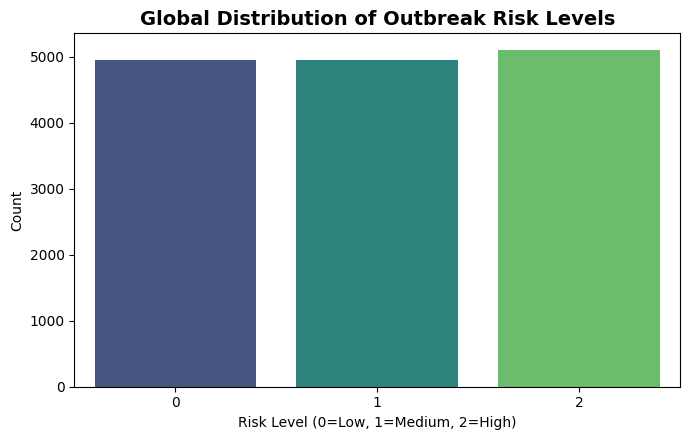

In [4]:
# Global Target Distribution
# =============================================================================
plt.figure(figsize=(7, 4.5))
sns.countplot(x="Target", data=df, palette="viridis")
plt.title("Global Distribution of Outbreak Risk Levels", fontsize=14, fontweight='bold')
plt.xlabel("Risk Level (0=Low, 1=Medium, 2=High)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

- So here our Target variable is Balenced

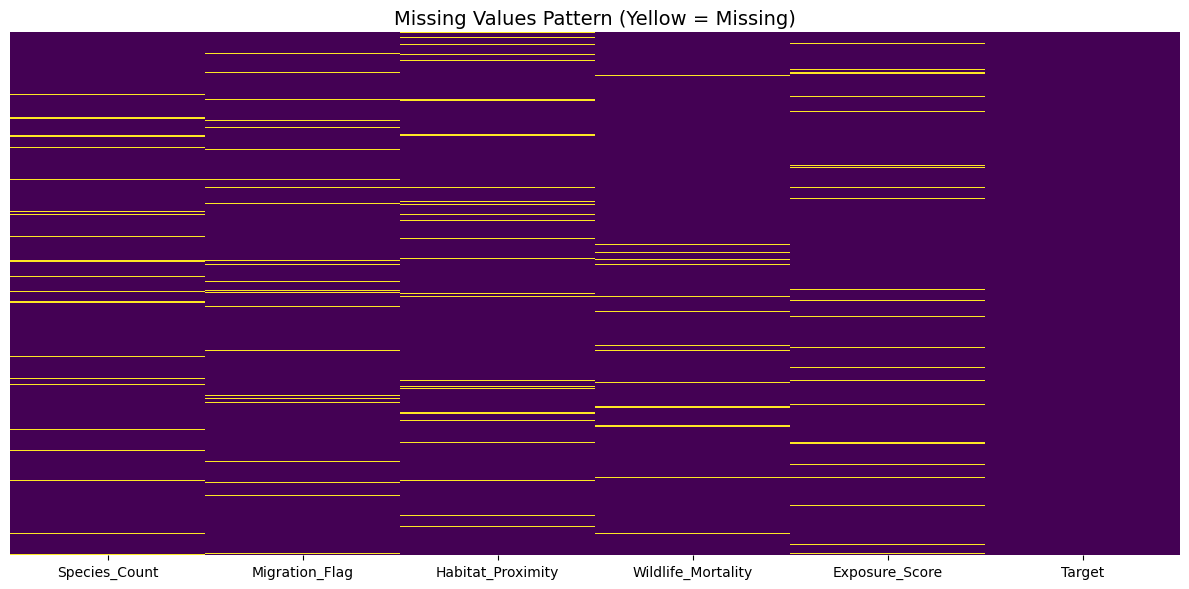

In [5]:
# =============================================================================
#  Missing Values Heatmap (whole dataset)
# =============================================================================
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Pattern (Yellow = Missing)", fontsize=14)
plt.tight_layout()
plt.show()

- Wherever the yellow lines is there all are missing values, Assume approximately 5% of missing values is there

# EDA per Client (wildlife)
-------------------------

C:\Users\dayav\AppData\Local\Temp\ipykernel_29528\2620016779.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\AppData\Local\Temp\ipykernel_29528\2620016779.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\AppData\Local\Temp\ipykernel_29528\2620016779.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
C:\Users\dayav\A

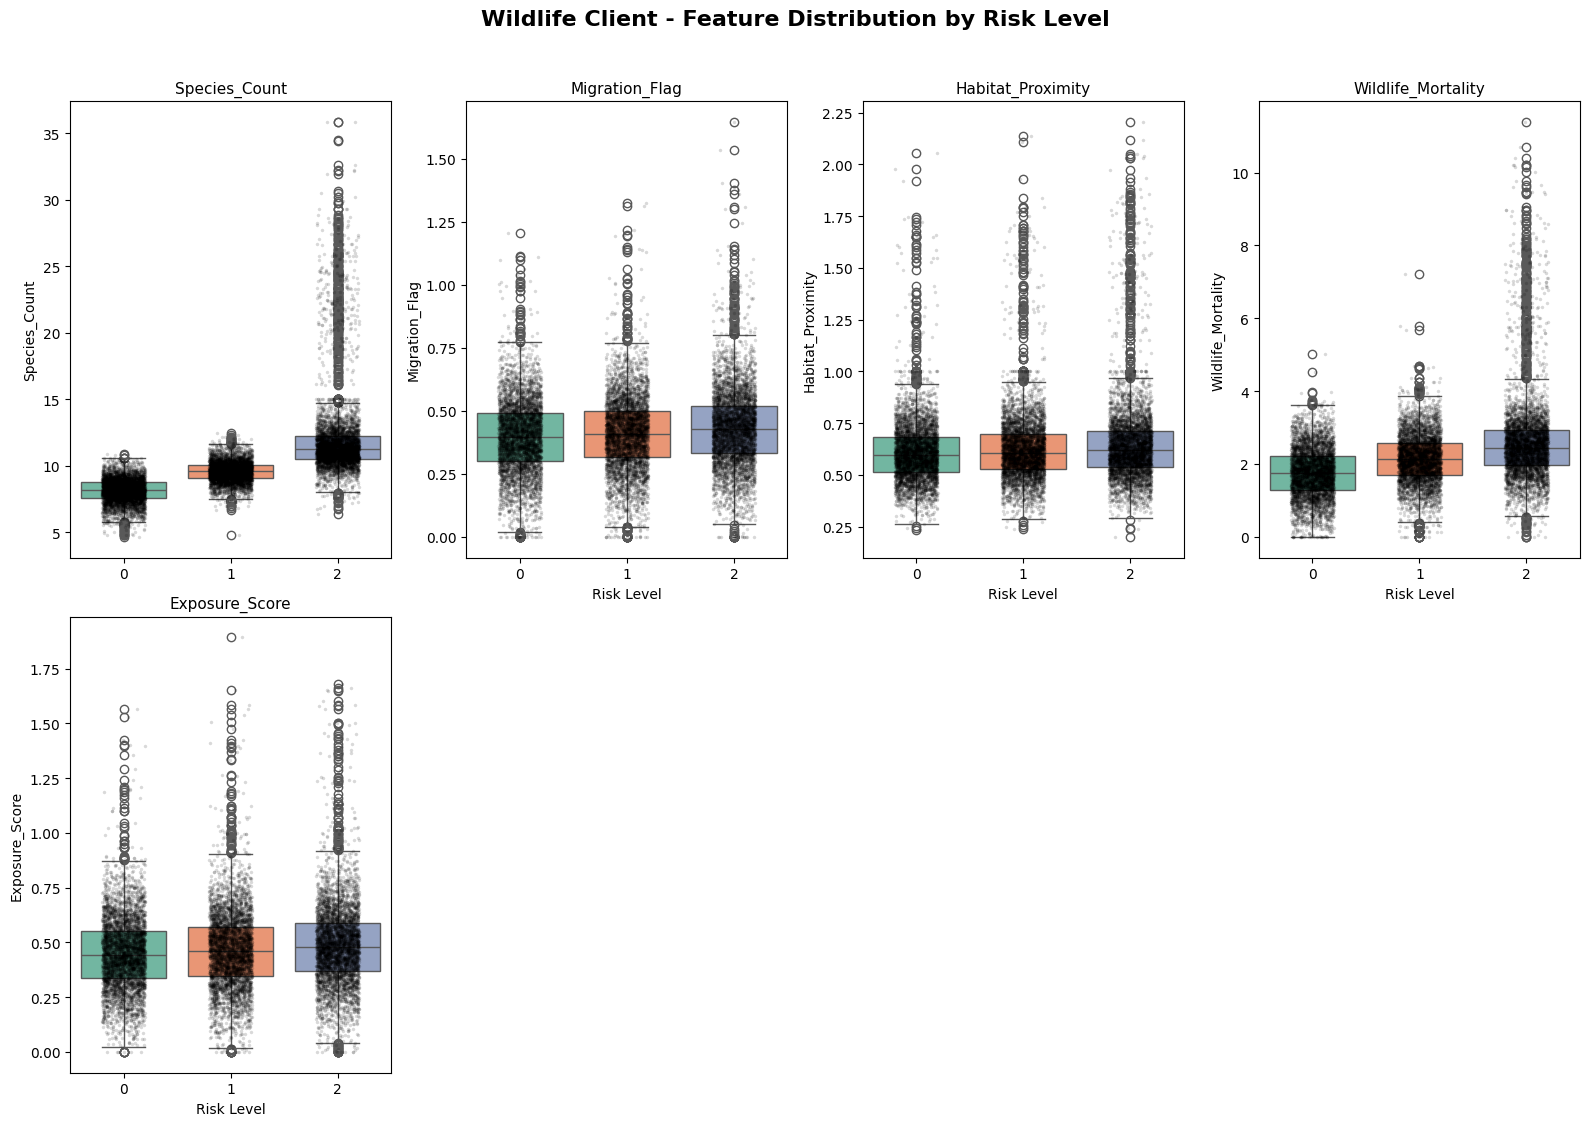

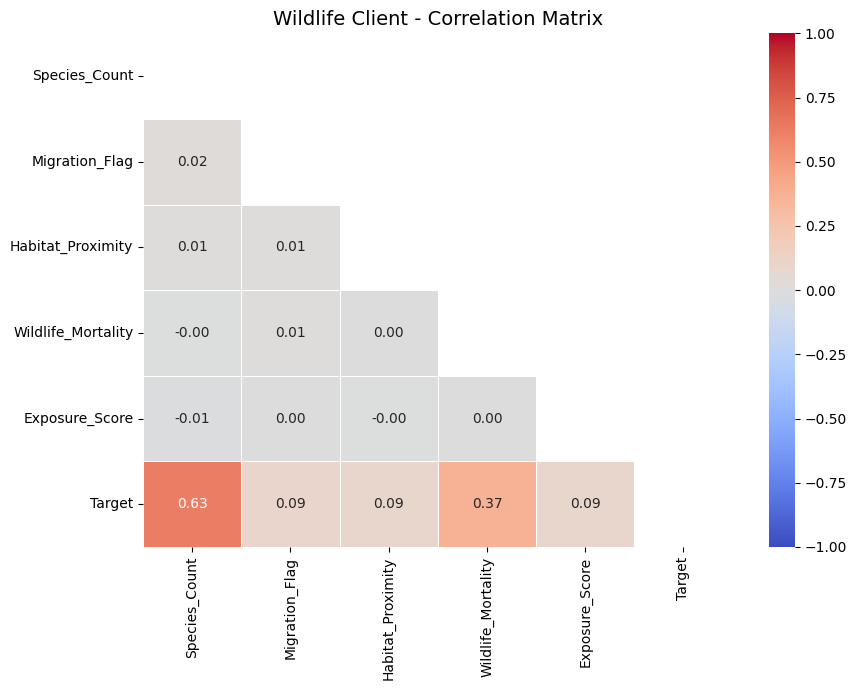

In [6]:
def plot_client_eda(client_df, client_name, figsize=(16, 12)):
    numeric_cols = client_df.select_dtypes(include=np.number).columns.tolist()
    if "Target" in numeric_cols:
        numeric_cols.remove("Target")
    
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=figsize)
    axes = axes.flatten()
    
    # Boxplots + Violin + strip (for small n we skip strip)
    for i, col in enumerate(numeric_cols):
        sns.boxplot(x="Target", y=col, data=client_df, ax=axes[i], palette="Set2")
        sns.stripplot(x="Target", y=col, data=client_df, 
                      color='k', alpha=0.15, size=2.5, jitter=0.2, ax=axes[i])
        axes[i].set_title(f"{col}", fontsize=11)
        axes[i].set_xlabel("Risk Level" if i >= len(numeric_cols)-4 else "")
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f"{client_name} - Feature Distribution by Risk Level", 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    plt.figure(figsize=(9, 7))
    corr = client_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, linewidths=0.5)
    plt.title(f"{client_name} - Correlation Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()


# Run EDA for each client
plot_client_eda(df,     "Wildlife Client",     figsize=(16, 11))


1. Wildlife Client Insights:
- Wildlife client data shows Species_Count strongly correlates (0.63) with risk level, with higher counts in high-risk groups. Wildlife_Mortality (0.37) also rises with risk. Migration_Flag, Habitat_Proximity, and Exposure_Score exhibit weak correlations and minimal separation across low, medium, and high risk levels..



Feature correlation with target (Target):
Target                1.000
Species_Count         0.628
Wildlife_Mortality    0.368
Migration_Flag        0.095
Habitat_Proximity     0.087
Exposure_Score        0.086
Name: Target, dtype: float64


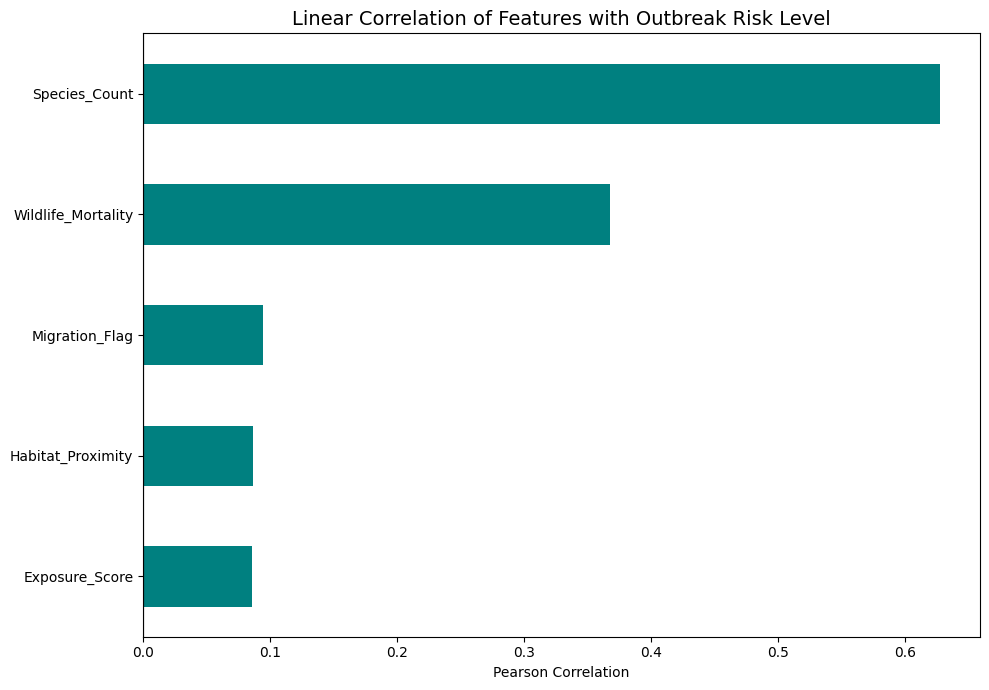

In [7]:
# =============================================================================
#  Feature importance proxy using simple correlation with target
# =============================================================================
correlations = df.corr(numeric_only=True)['Target'].sort_values(ascending=False)

print("\nFeature correlation with target (Target):")
print(correlations.round(3))

plt.figure(figsize=(10, 7))
correlations.drop("Target").sort_values().plot(kind='barh', color='teal')
plt.axvline(0, color='black', lw=0.8)
plt.title("Linear Correlation of Features with Outbreak Risk Level", fontsize=14)
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()



This bar chart shows Pearson correlations with Outbreak Risk Level for wildlife data. Species_Count has the strongest positive correlation (~0.58), followed by Wildlife_Mortality (~0.42). Migration_Flag, Habitat_Proximity, and Exposure_Score exhibit weaker positive correlations (~0.15-0.20), indicating limited linear predictive power for risk level.

# **Sweetviz for Auto EDA**

In [8]:
import sweetviz as sv
import pandas as pd

report = sv.analyze(df)
report.show_html("sweetviz_full_report_wildlife.html")


c:\Users\dayav\anaconda3\envs\aienv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweetviz_full_report_wildlife.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Distribution of each column

Plotting 5 features with actual data (out of 5 numeric columns)
Valid features: ['Species_Count', 'Migration_Flag', 'Habitat_Proximity', 'Wildlife_Mortality', 'Exposure_Score']


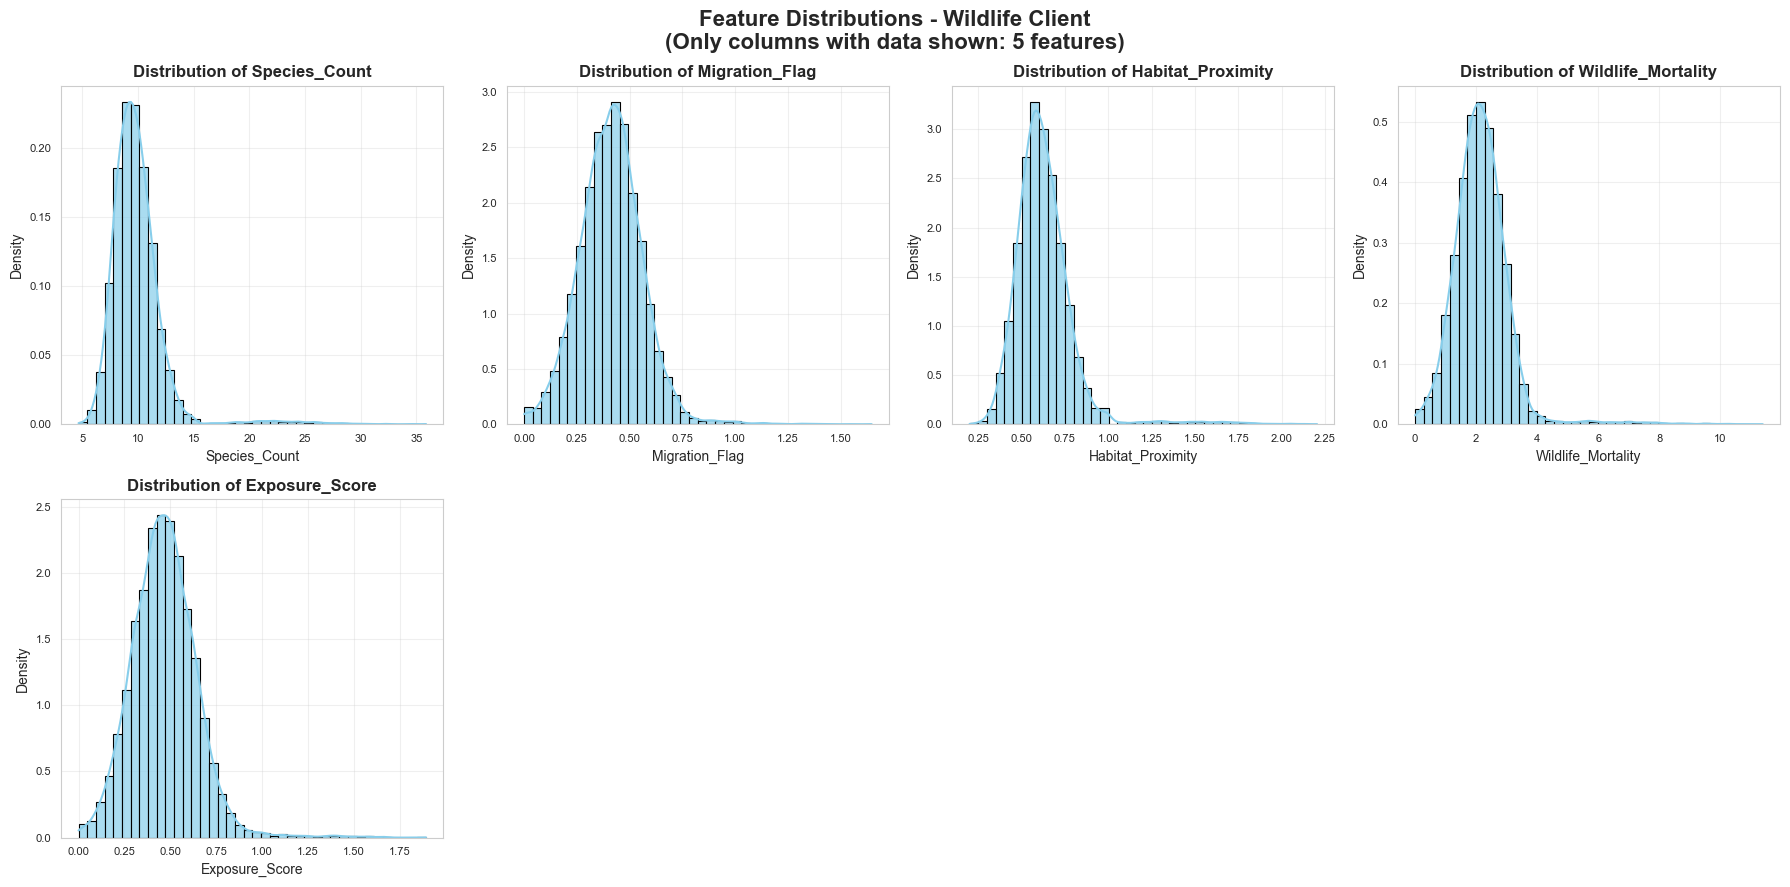

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: nicer style
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-pastel')  # safe to use

# Remove the target column from plotting
if 'Target' in df.columns:
    target_col = 'Target'
else:
    target_col = None

# Get numeric columns that are NOT completely empty (have at least one non-null value)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove target if present
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Keep only columns that have at least one real value (not fully NaN)
valid_cols = [col for col in numeric_cols if df[col].notna().any()]

print(f"Plotting {len(valid_cols)} features with actual data (out of {len(numeric_cols)} numeric columns)")
print("Valid features:", valid_cols)

# If no valid columns, stop early
if len(valid_cols) == 0:
    print("No features with data found to plot.")
else:
    # Grid setup
    n_cols_plot = min(4, len(valid_cols))  # max 4 per row
    n_rows = (len(valid_cols) + 3) // 4

    fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
    axes = axes.flatten()

    for i, col in enumerate(valid_cols):
        sns.histplot(
            data=df[col], 
            kde=True,
            ax=axes[i],
            color='skyblue',
            edgecolor='black',
            alpha=0.7,
            bins=40,
            stat="density",
            linewidth=0.8
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Density', fontsize=10)
        axes[i].grid(True, alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Main title
    plt.suptitle(f'Feature Distributions - Wildlife Client\n'
                 f'(Only columns with data shown: {len(valid_cols)} features)', 
                 fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.show()

Wildlife client histograms reveal right-skewed distributions for Species_Count, Habitat_Proximity, Wildlife_Mortality, and Exposure_Score, with most values near zero. Migration_Flag appears bimodal around 0-1. All features show heavy tails, indicating rare high values drive risk differences rather than typical observations.

## Qunatile- Quantile plot

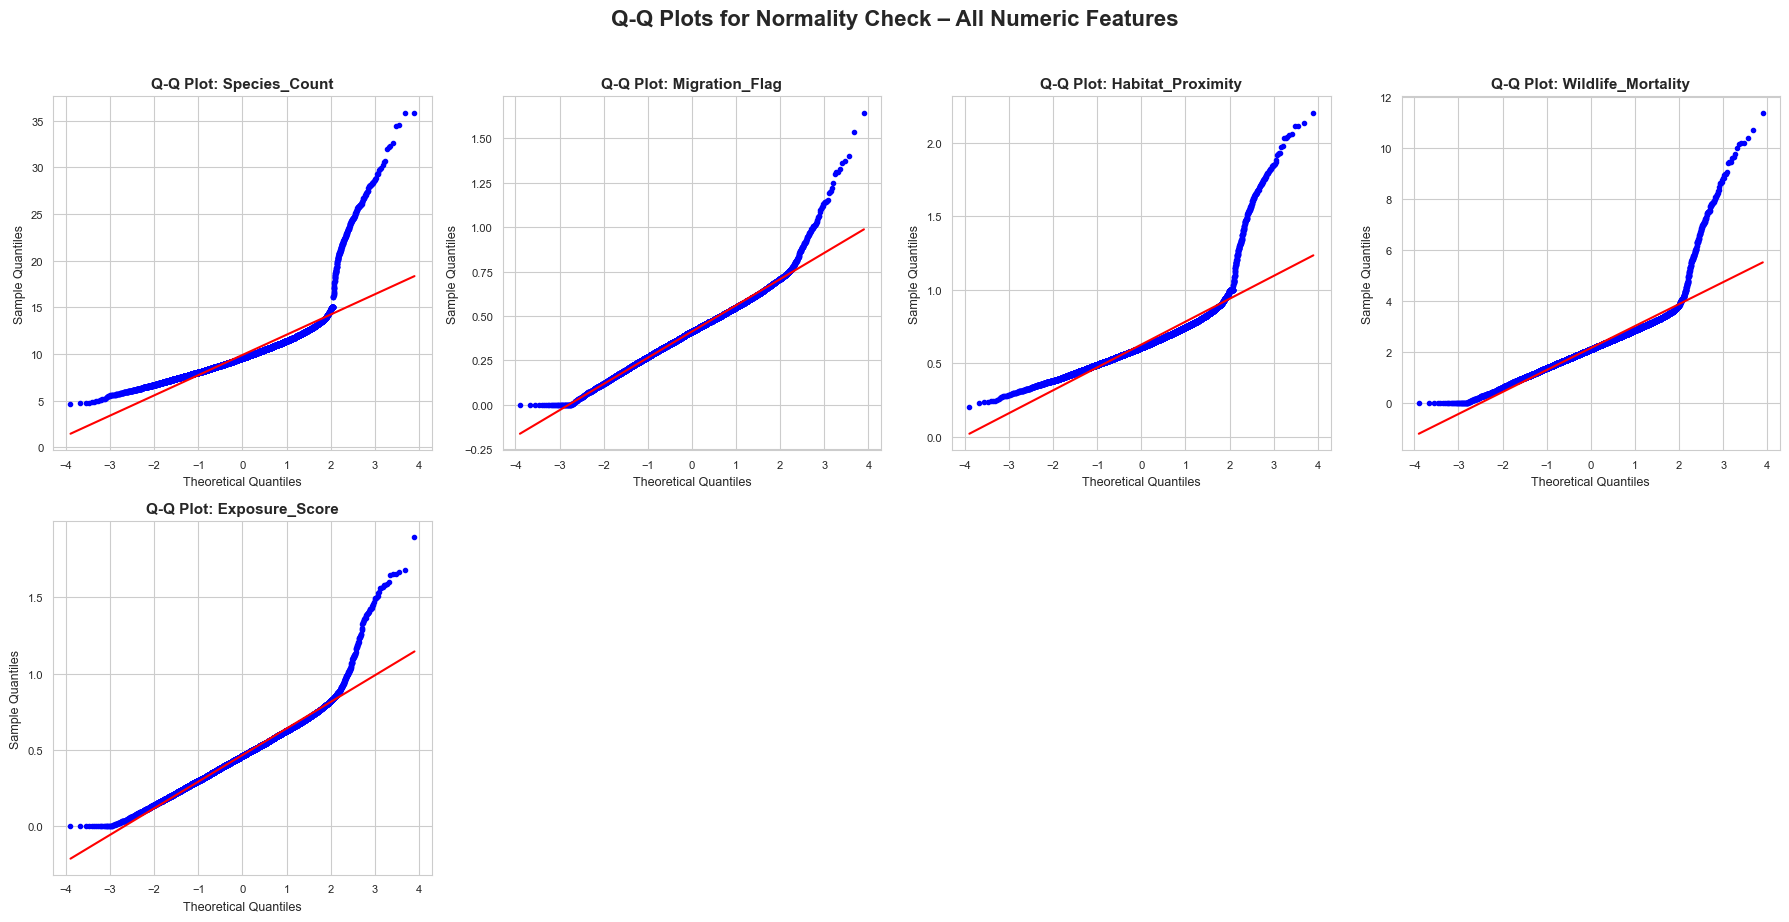

In [10]:
import scipy.stats as stats
sns.set_style("whitegrid")

# Get all numeric features (exclude target)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'Target' in numeric_cols:
    numeric_cols.remove('Target')

# Grid setup: 4 columns, auto rows
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Q-Q plot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Theoretical Quantiles', fontsize=9)
    axes[i].set_ylabel('Sample Quantiles', fontsize=9)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots for Normality Check – All Numeric Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Q-Q plots for wildlife numeric features show clear deviations from normality. Species_Count, Habitat_Proximity, Wildlife_Mortality, and Exposure_Score exhibit strong right-skewness with upward tail curvature. Migration_Flag deviates markedly, suggesting discrete or bimodal nature. None align with the reference line, confirming non-normal distributions.

## Scatter plot

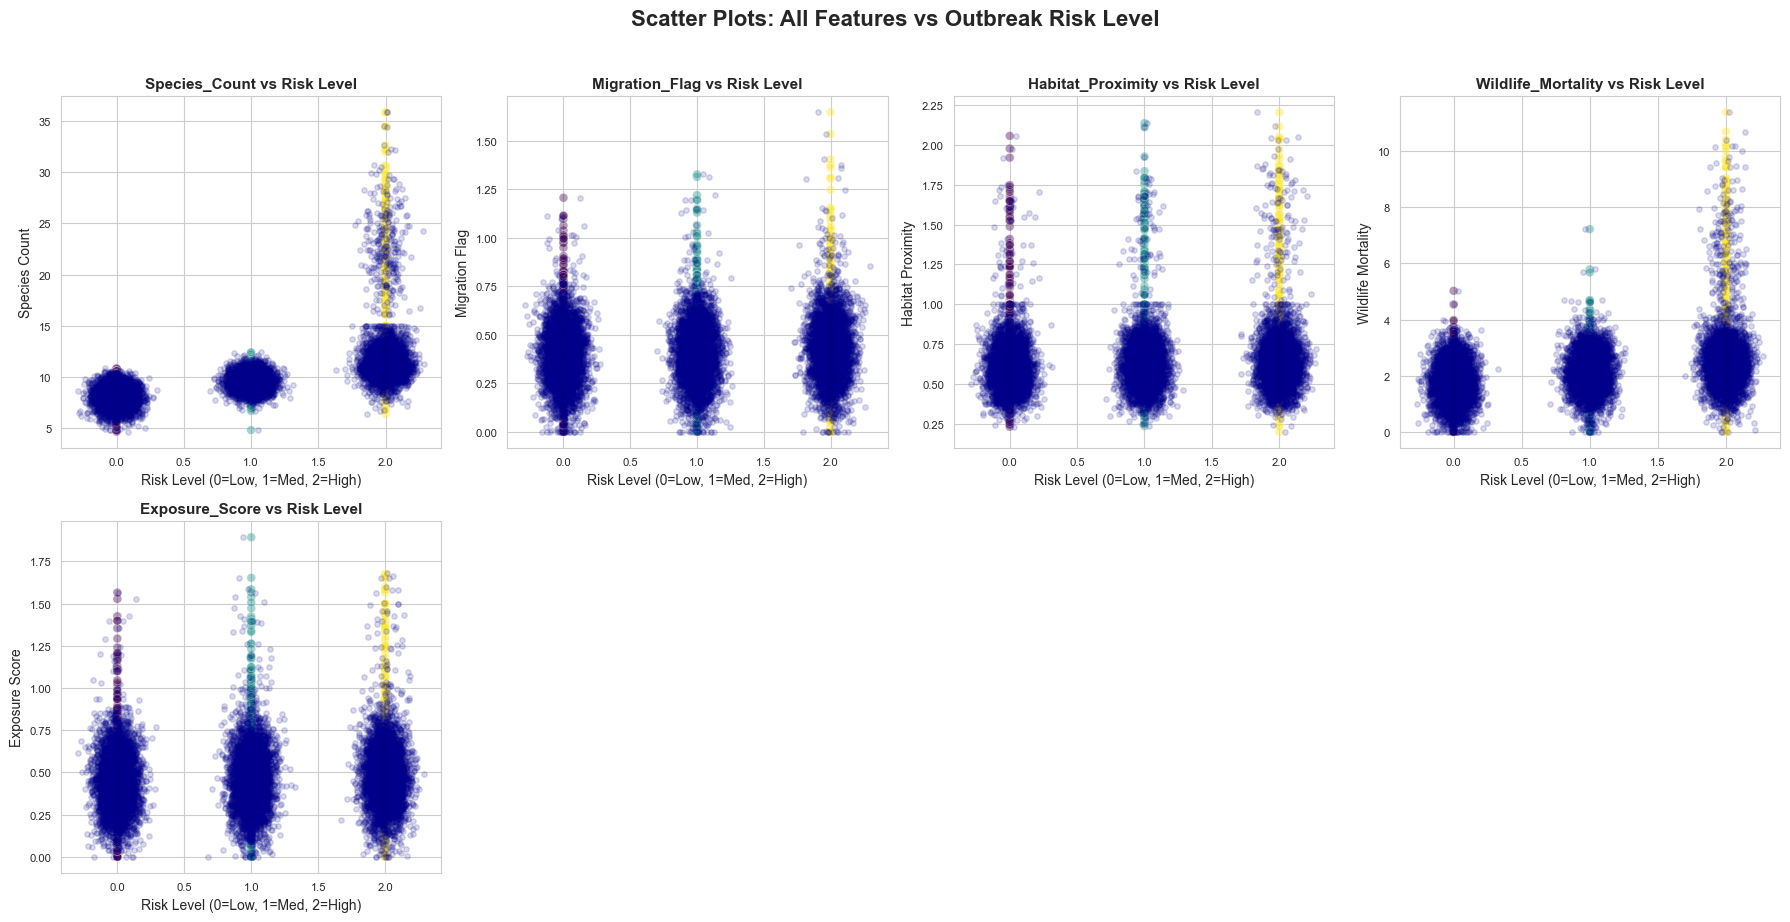

In [11]:
fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(
        x="Target",
        y=col,
        data=df,
        ax=axes[i],
        alpha=0.4,
        s=40,
        hue="Target",
        palette="viridis",
        legend=False
    )
    # Add small jitter to x-axis to better see density
    axes[i].scatter(
        df["Target"] + np.random.normal(0, 0.08, len(df)),
        df[col],
        alpha=0.15,
        s=15,
        color='darkblue'
    )
    axes[i].set_title(f'{col} vs Risk Level', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Risk Level (0=Low, 1=Med, 2=High)')
    axes[i].set_ylabel(col.replace('_', ' '), fontsize=10)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scatter Plots: All Features vs Outbreak Risk Level',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Scatter plots reveal Species_Count and Wildlife_Mortality increase markedly with higher Outbreak Risk Levels (0=Low, 1=Med, 2=High), showing clear separation. Habitat_Proximity and Exposure_Score exhibit moderate upward trends. Migration_Flag shows minimal differentiation, with dense overlap across all risk categories.

# **`Final EDA Summary on wildlife Dataset`**
EDA for wildlife outbreak risk data shows strong right-skewness and non-normality across features. Species_Count correlates most strongly (0.63) with risk level, followed by Wildlife_Mortality (0.37). Other features (Migration_Flag, Habitat_Proximity, Exposure_Score) exhibit weak relationships and limited separation between low, medium, and high risk classes.